<h1>Taxi demand forecasting using machine learning</h1>

## Project description

The goal of this project is to predict the number of taxi orders for the next hour using historical airport taxi request data. Sweet Lift Taxi wants to anticipate periods of high demand to attract more drivers when needed.

The first step is to examine the temporal structure of the data and aggregate the time series into one hour intervals to represent the total taxi demand for each period.

Next, the time series is analyzed to identify trends, seasonality, and recurring demand patterns. Based on this analysis, predictive features are created using time lags and moving averages to capture the patterns observed in the series.

Finally, four regression models are trained and compared: Linear Regression, Random Forest, LightGBM, and CatBoost. The final model is selected based on its performance on the test set using the Root Mean Squared Error (RMSE), with the requirement of achieving an RMSE below 48.

## Preprocessing

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*pkg_resources is deprecated.*")

In [2]:
import pandas as pd

import time

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from statsmodels.tsa.seasonal import seasonal_decompose 

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from ticks_configuration import setup_minor_ticks
from matplotlib.ticker import AutoMinorLocator, FuncFormatter


In [3]:
# Load the dataset, using the date column as the index and converting it to datetime
df_taxi = pd.read_csv('datasets/taxi.csv', sep=',', index_col=[0], parse_dates=[0])

In [4]:
df_taxi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [5]:
print(f"Missing values in the index: {df_taxi.index.hasnans}")

Missing values in the index: False


In [6]:
print(f"Dataset columns: {list(df_taxi.columns)}")

Dataset columns: ['num_orders']


In [7]:
print(f"Number of duplicate index values: {df_taxi.index.duplicated().sum()}")

Number of duplicate index values: 0


In [8]:
print(df_taxi.head())

                     num_orders
datetime                       
2018-03-01 00:00:00           9
2018-03-01 00:10:00          14
2018-03-01 00:20:00          28
2018-03-01 00:30:00          20
2018-03-01 00:40:00          32


In [9]:
print("Time interval frequency between observations:\n"
    f"{df_taxi.index.to_series().diff().value_counts()}"
)

Time interval frequency between observations:
datetime
0 days 00:10:00    26495
Name: count, dtype: int64


In [10]:
# Sort the DataFrame by the date index to ensure it is in chronological order
df_taxi = df_taxi.sort_index()

In [11]:
df_taxi['num_orders'].index.min()

Timestamp('2018-03-01 00:00:00')

## Exploratory time series analysis

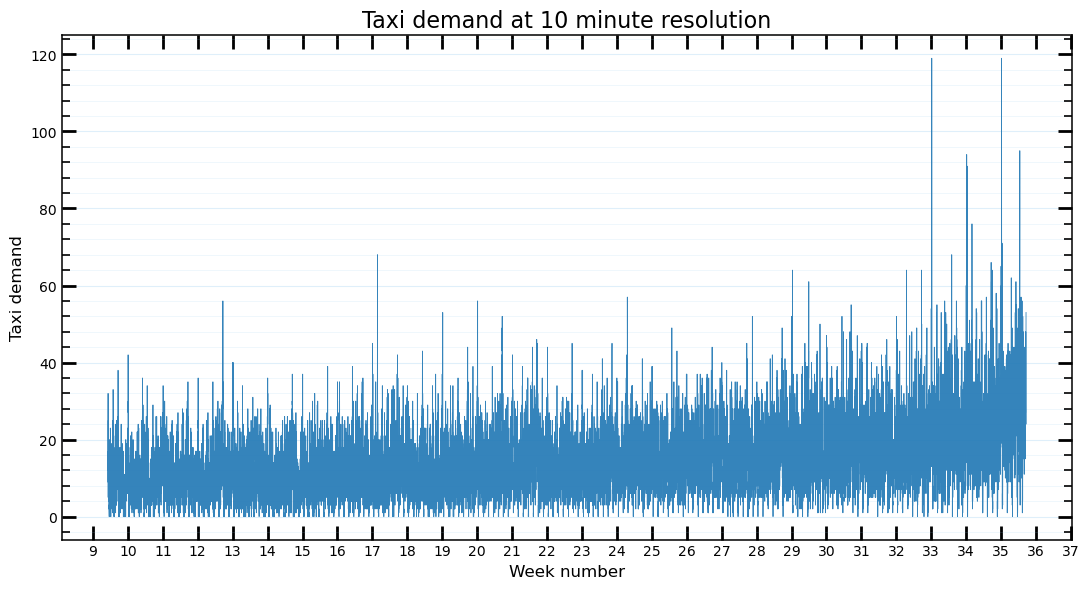

In [12]:
# Plot the taxi demand over time at 10 minute resolution
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(df_taxi.index.to_numpy(), df_taxi['num_orders'].to_numpy(), linewidth=0.6, alpha=0.9)

ax.set_xlabel('Week number', fontsize=12)
ax.set_ylabel('Taxi demand', fontsize=12)
ax.set_title('Taxi demand at 10 minute resolution', fontsize=16)

for side in ['top', 'right', 'bottom', 'left']:
    ax.spines[side].set_linewidth(1.1)

ax.tick_params(labelsize=10)
ax.tick_params(axis='x', rotation=0)

ax.set_axisbelow(True)
ax.grid(axis='y', which='major', linewidth=0.8, alpha=0.28, color='#8EC7F0')
ax.grid(axis='y', which='minor', linewidth=0.5, alpha=0.20, color='#8EC7F0')

ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# Label dates using the ISO week number (a year can have up to 53 weeks)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{mdates.num2date(x).isocalendar().week}"))

# Configure major and minor ticks, including tick direction on each side of the plot
setup_minor_ticks(
    ax,
    x_minor_divisions=1,
    y_minor_divisions=5,
    major=(10, 2),
    minor=(6, 1.2),
    sides=dict(top=True, right=True, bottom=True, left=True),
    direction_top='in',
    direction_bottom='in',
    direction_left='in',
    direction_right='in'
)

plt.tight_layout()
plt.show()

In [13]:
# Create a new DataFrame to store time based features
# Group the data into one hour intervals and calculate the total number of orders for each interval
df_time_features = df_taxi.resample('1h').sum()

# Extract time components from the index and calculate the average demand
# to analyze patterns by hour, day of the week, week, and month
df_time_features['hour'] = df_time_features.index.hour
series_hour_mean = df_time_features.groupby('hour')['num_orders'].mean()

df_time_features['dayofweek'] = df_time_features.index.dayofweek
series_dayofweek_mean = df_time_features.groupby('dayofweek')['num_orders'].mean()

df_time_features['week'] = df_time_features.index.isocalendar().week
series_week_mean = df_time_features.groupby('week')['num_orders'].mean()

df_time_features['month'] = df_time_features.index.month
series_month_mean = df_time_features.groupby('month')['num_orders'].mean()

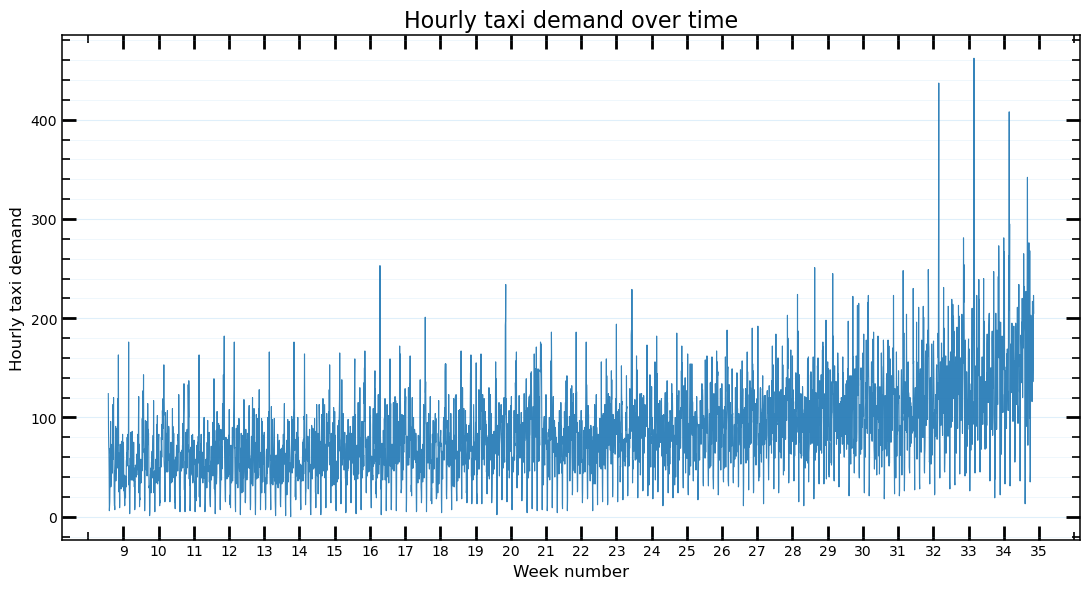

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(df_time_features.index.to_numpy(), df_time_features['num_orders'].to_numpy(), linewidth=0.8, alpha=0.9)

ax.set_xlabel('Week number', fontsize=12)
ax.set_ylabel('Hourly taxi demand', fontsize=12)
ax.set_title('Hourly taxi demand over time', fontsize=16)

for side in ['top', 'right', 'bottom', 'left']:
    ax.spines[side].set_linewidth(1.1)

ax.tick_params(labelsize=10)
ax.tick_params(axis='x', rotation=0)

# Label dates using the ISO week number (a year can have up to 53 weeks)
week_ticks = df_time_features.resample('1W').sum().index
ax.set_xticks(week_ticks)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{mdates.num2date(x).isocalendar().week}"))

# Draw the grid behind the plotted line
ax.set_axisbelow(True)

ax.grid(axis='y', which='major', linewidth=0.8, alpha=0.28, color='#8EC7F0')
ax.grid(axis='y', which='minor', linewidth=0.5, alpha=0.20, color='#8EC7F0')

ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# Configure major and minor ticks, including tick direction on each side of the plot
setup_minor_ticks(
    ax,
    x_minor_divisions=1,
    y_minor_divisions=5,
    major=(10, 2),
    minor=(6, 1.2),
    sides=dict(top=True, right=True, bottom=True, left=True),
    direction_top='in',
    direction_bottom='in',
    direction_left='in',
    direction_right='in'
)

plt.tight_layout()
plt.show()

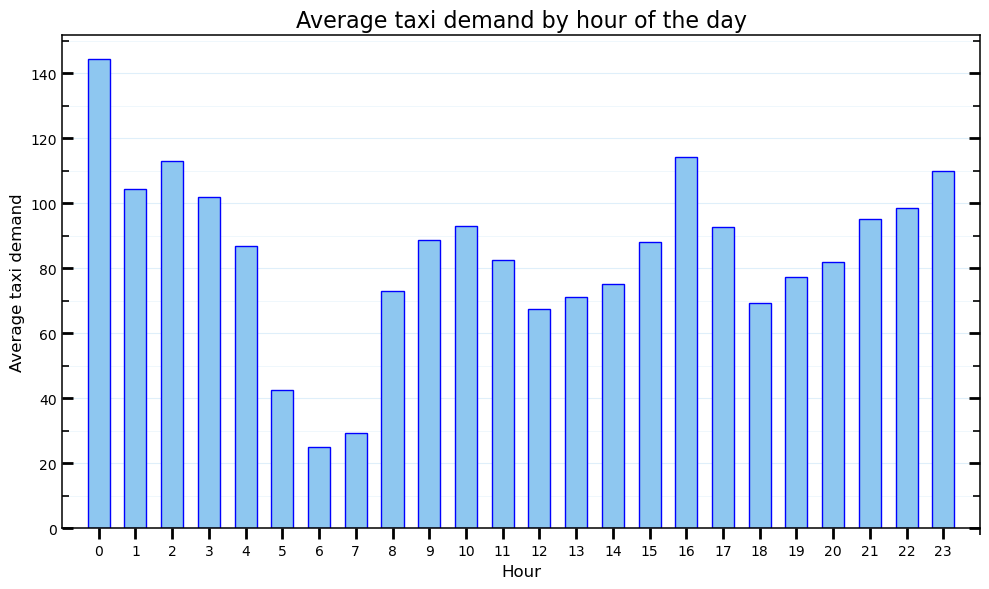

In [15]:
# Plot the average taxi demand for each hour of the day
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(series_hour_mean.index, series_hour_mean.values,
    edgecolor='blue', width=0.6, linewidth=1.0, color='#8EC7F0', alpha=1
)

ax.set_xlabel('Hour', fontsize=12)
ax.set_ylabel('Average taxi demand', fontsize=12)
ax.set_title('Average taxi demand by hour of the day', fontsize=16)

for side in ['top', 'right', 'bottom', 'left']:
    ax.spines[side].set_linewidth(1.1)

ax.tick_params(labelsize=10)
ax.tick_params(axis='x', rotation=0)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{hour}' for hour in range(24)])

ax.set_axisbelow(True)

ax.grid(axis='y', which='major', linewidth=0.8, alpha=0.28, color='#8EC7F0')
ax.grid(axis='y', which='minor', linewidth=0.5, alpha=0.20, color='#8EC7F0')

ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# Configure major and minor ticks, including tick direction on each side of the plot
setup_minor_ticks(
    ax,
    x_minor_divisions=1,
    y_minor_divisions=2,
    major=(8, 2),
    minor=(5, 1.2),
    sides=dict(top=False, right=True, bottom=True, left=True),
    direction_top='in',
    direction_bottom='out',
    direction_left='in',
    direction_right='in'
)

ax.set_xlim(-1, 24)

plt.tight_layout()
plt.show()

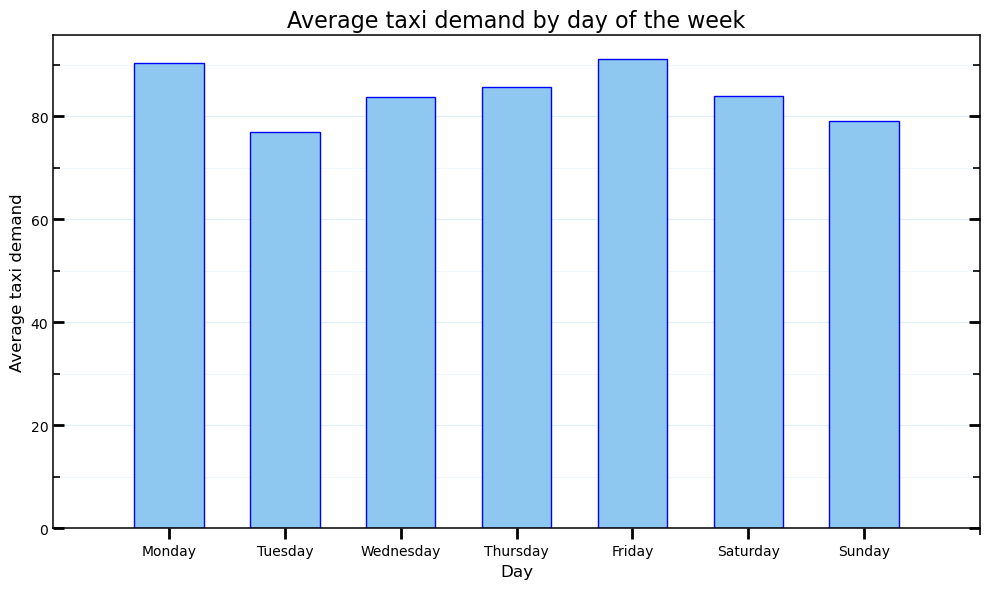

In [16]:
# Plot the average taxi demand by day of the week
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(series_dayofweek_mean.index, series_dayofweek_mean.values,
    edgecolor='blue', width=0.6, linewidth=1.0, color='#8EC7F0', alpha=1
)

ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Average taxi demand', fontsize=12)
ax.set_title('Average taxi demand by day of the week', fontsize=16)

for side in ['top', 'right', 'bottom', 'left']:
    ax.spines[side].set_linewidth(1.1)

ax.tick_params(labelsize=10)
ax.tick_params(axis='x', rotation=0)

# Replace numeric day labels (0-6) with weekday names
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ax.set_xticks(range(7))
ax.set_xticklabels(days)

ax.set_axisbelow(True)

ax.grid(axis='y', which='major', linewidth=0.8, alpha=0.28, color='#8EC7F0')
ax.grid(axis='y', which='minor', linewidth=0.5, alpha=0.20, color='#8EC7F0')

ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# Configure major and minor ticks, including tick direction on each side of the plot
setup_minor_ticks(
    ax,
    x_minor_divisions=1,
    y_minor_divisions=2,
    major=(8, 2),
    minor=(5, 1.2),
    sides=dict(top=False, right=True, bottom=True, left=True),
    direction_top='in',
    direction_bottom='out',
    direction_left='in',
    direction_right='in'
)

ax.set_xlim(-1, 7)

plt.tight_layout()
plt.show()

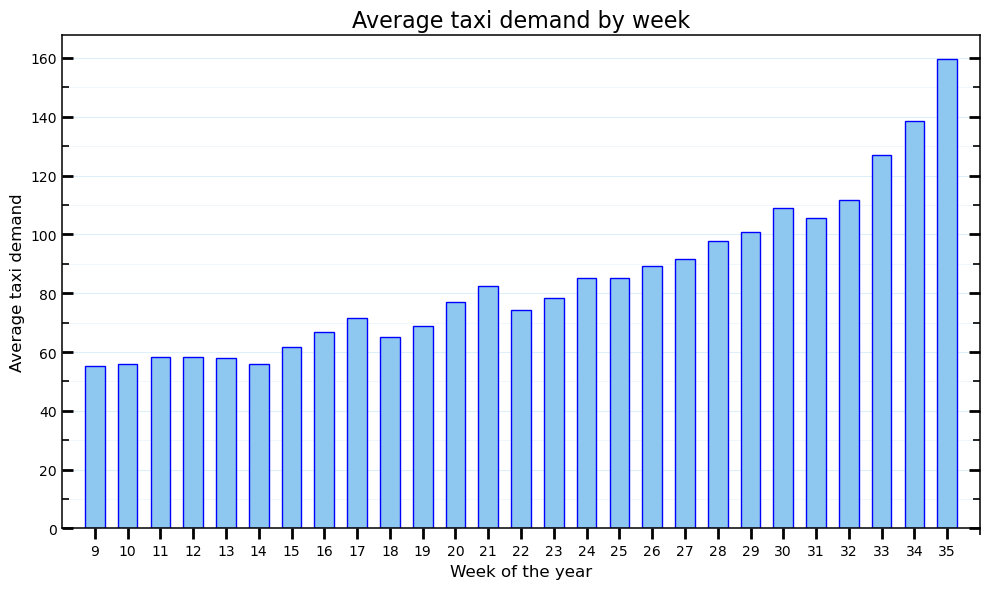

In [17]:
# Plot the average taxi demand by week
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(series_week_mean.index, series_week_mean.values,
    edgecolor='blue', width=0.6, linewidth=1.0, color='#8EC7F0', alpha=1
)

ax.set_xlabel('Week of the year', fontsize=12)
ax.set_ylabel('Average taxi demand', fontsize=12)
ax.set_title('Average taxi demand by week', fontsize=16)

for side in ['top', 'right', 'bottom', 'left']:
    ax.spines[side].set_linewidth(1.1)

ax.tick_params(labelsize=10)
ax.tick_params(axis='x', rotation=0)

# Show x-axis ticks for the weeks available in the dataset
ax.set_xticks(series_week_mean.index)

ax.set_axisbelow(True)

ax.grid(axis='y', which='major', linewidth=0.8, alpha=0.28, color='#8EC7F0')
ax.grid(axis='y', which='minor', linewidth=0.5, alpha=0.20, color='#8EC7F0')

ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# Configure major and minor ticks, including tick direction on each side of the plot
setup_minor_ticks(
    ax,
    x_minor_divisions=1,
    y_minor_divisions=2,
    major=(8, 2),
    minor=(5, 1.2),
    sides=dict(top=False, right=True, bottom=True, left=True),
    direction_top='in',
    direction_bottom='out',
    direction_left='in',
    direction_right='in'
)

ax.set_xlim(series_week_mean.index.min() - 1, series_week_mean.index.max() + 1)

plt.tight_layout()
plt.show()

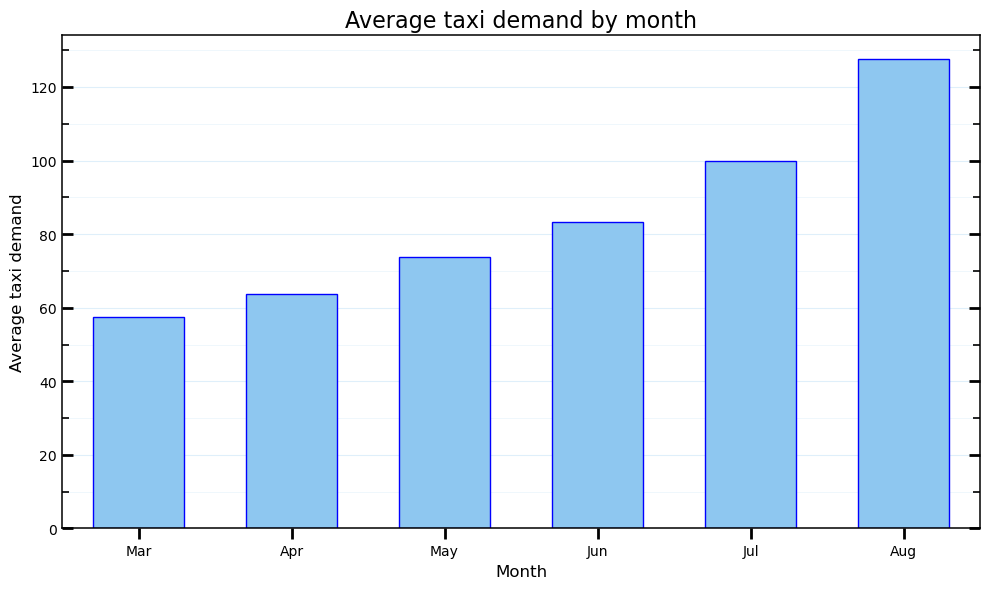

In [18]:
# Plot the average taxi demand by month
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(series_month_mean.index, series_month_mean.values,
    edgecolor='blue', width=0.6, linewidth=1.0, color='#8EC7F0', alpha=1
)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average taxi demand', fontsize=12)
ax.set_title('Average taxi demand by month', fontsize=16)

for side in ['top', 'right', 'bottom', 'left']:
    ax.spines[side].set_linewidth(1.1)

ax.tick_params(labelsize=10)
ax.tick_params(axis='x', rotation=0)

# Replace month numbers with month abbreviations
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks(series_month_mean.index)
ax.set_xticklabels([months[i - 1] for i in series_month_mean.index])

ax.set_axisbelow(True)

ax.grid(axis='y', which='major', linewidth=0.8, alpha=0.28, color='#8EC7F0')
ax.grid(axis='y', which='minor', linewidth=0.5, alpha=0.20, color='#8EC7F0')

ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# Configure major and minor ticks, including tick direction on each side of the plot
setup_minor_ticks(
    ax,
    x_minor_divisions=1,
    y_minor_divisions=2,
    major=(8, 2),
    minor=(5, 1.2),
    sides=dict(top=False, right=True, bottom=True, left=True),
    direction_top='in',
    direction_bottom='out',
    direction_left='in',
    direction_right='in'
)

ax.set_xlim(series_month_mean.index.min() - 0.5, series_month_mean.index.max() + 0.5)

plt.tight_layout()
plt.show()

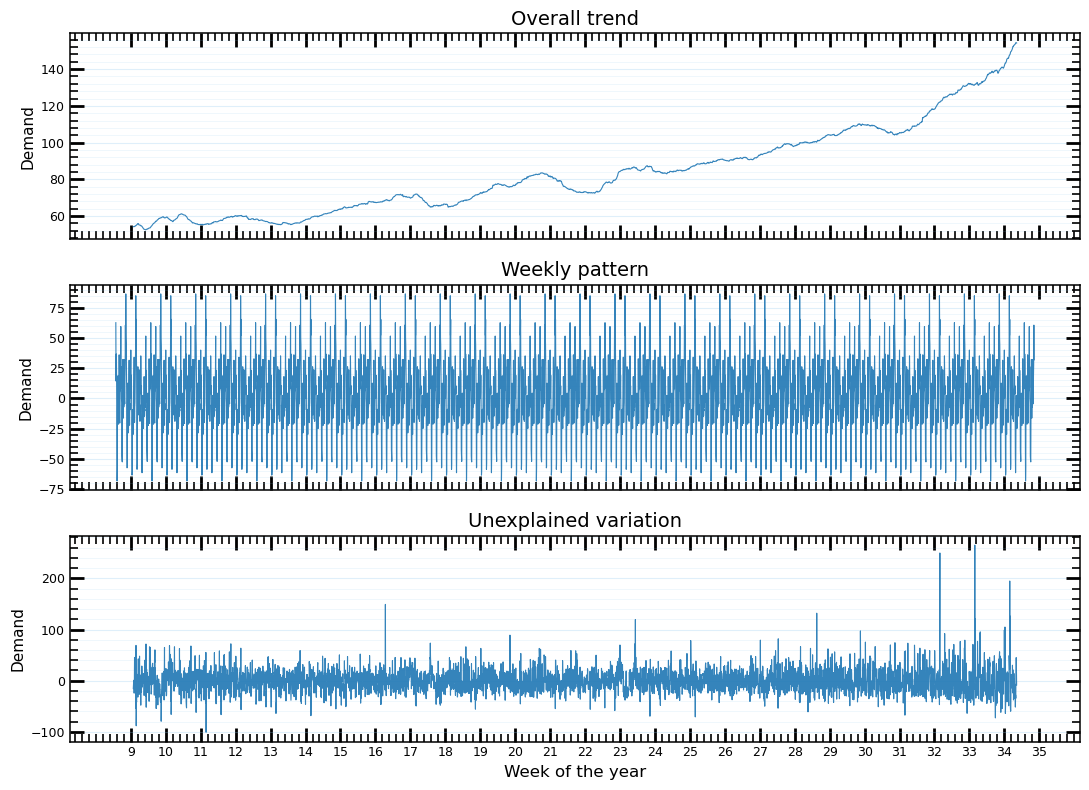

In [19]:
# Decompose the time series with a weekly pattern to analyze its trend, seasonality, and residuals

# We use an additive model because the seasonal variation keeps a similar amplitude,
# as observed in the 'Hourly taxi demand over time' plot, even when the average demand changes.

# period = 168 because we want to capture weekly seasonality
# 7 days * 24 hours = 168 hours
decomposed = seasonal_decompose(
    df_time_features['num_orders'],
    model='additive',
    period=168
)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

components = [
    (decomposed.trend, 'Overall trend'),
    (decomposed.seasonal, 'Weekly pattern'),
    (decomposed.resid, 'Unexplained variation')
]

for ax, (series, title) in zip(axes, components):
    ax.plot(
        series.index.to_numpy(),
        series.to_numpy(),
        linewidth=0.8,
        alpha=0.9
    )

    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Demand', fontsize=11)

    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_linewidth(1.1)

    ax.tick_params(labelsize=9)

    ax.set_axisbelow(True)
    ax.grid(axis='y', which='major', linewidth=0.8, alpha=0.28, color='#8EC7F0')
    ax.grid(axis='y', which='minor', linewidth=0.5, alpha=0.20, color='#8EC7F0')

    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    setup_minor_ticks(
        ax,
        x_minor_divisions=5,
        y_minor_divisions=5,
        major=(10, 2),
        minor=(6, 1.2),
        sides=dict(top=True, right=True, bottom=True, left=True),
        direction_top='in',
        direction_bottom='in',
        direction_left='in',
        direction_right='in'
    )

axes[-1].set_xlabel('Week of the year', fontsize=12)

week_ticks = df_time_features.resample('1W').sum().index
axes[-1].set_xticks(week_ticks)

axes[-1].xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{mdates.num2date(x).isocalendar().week}")
)

plt.tight_layout()
plt.show()

The plots show an upward trend during the analyzed period, with higher demand in the last few weeks. This indicates that demand changes over time and that recent observations provide useful information for building predictive features.

The average hourly demand decreases during the early morning, especially between 5:00 and 7:00 a.m., and increases at different times throughout the day.

The average daily demand shows that Mondays and Fridays have the highest demand, while Tuesdays and Sundays have relatively lower average demand.

The weekly analysis and the time series decomposition confirm a recurring weekly pattern, along with the upward trend observed in the series.

## Time feature engineering

Based on the observations from the exploratory analysis, time based features are created for model training.

The features hour and dayofweek are added to represent the hour of the day and the day of the week for each observation. In addition, lag features from 1 to 24 hours are included to capture the recent behavior of the series and the daily pattern observed in the data. A 168 hour lag is also added to represent the same hour of the previous week and capture the weekly pattern identified during the exploratory analysis.

In [20]:
# Prepare the data for predictive modeling using lag features
df_with_lag_features = df_taxi.resample('1h').sum().copy()

random_state = 1010011

# Extract time features from the index to capture patterns related to the hour of the day and the day of the week
df_with_lag_features['hour'] = df_with_lag_features.index.hour
df_with_lag_features['dayofweek'] = df_with_lag_features.index.dayofweek

# Create lag features from 1 to 24 hours and one additional 168 hour lag to capture weekly patterns
for lag in range(1, 25):
    df_with_lag_features[f'lag_{lag}'] = df_with_lag_features['num_orders'].shift(lag)
df_with_lag_features['lag_168'] = df_with_lag_features['num_orders'].shift(168)

# Remove rows with missing values generated by the lag features
df_with_lag_features = df_with_lag_features.dropna()

# Create the training, validation, and test sets using an 80%, 10%, and 10% split,
# without shuffling the data to preserve the time order
features = df_with_lag_features.drop(columns=['num_orders'])
target = df_with_lag_features['num_orders']

features_train, features_temp, target_train, target_temp = train_test_split(features, target, test_size=0.2, shuffle=False)

features_valid, features_test, target_valid, target_test = train_test_split(features_temp, target_temp, test_size=0.5, shuffle=False)

## Model training

Four regression models are trained and compared to predict taxi demand for the next hour: Linear Regression, Random Forest, LightGBM, and CatBoost.

For each model, except Linear Regression, different hyperparameter configurations are evaluated to minimize the Root Mean Squared Error (RMSE) on the validation set. The best version of each model is then evaluated on the test set to compare their predictive performance under the same conditions.

The final model is selected based on the lowest RMSE achieved on the test set, with the requirement of keeping the RMSE below 48.

### Linear Regression

In [21]:
# Train the linear regression model and evaluate its performance on the validation and test sets
lr = LinearRegression()

# Training time
start = time.time()
lr.fit(features_train, target_train)
train_time = time.time() - start

preds_valid = lr.predict(features_valid)

valid_rmse = mean_squared_error(target_valid, preds_valid) ** 0.5
print(f'Validation RMSE: {valid_rmse:.4f}')

# Prediction time
start = time.time()
preds_test = lr.predict(features_test)
pred_time = time.time() - start

test_rmse = mean_squared_error(target_test, preds_test) ** 0.5
print(f'Test RMSE: {test_rmse:.4f}')

print(f"Training time: {train_time:.4f} s")
print(f"Prediction time: {pred_time:.4f} s")

Validation RMSE: 31.0984
Test RMSE: 34.9438
Training time: 0.0128 s
Prediction time: 0.0011 s


### Random Forest

In [22]:
# Hyperparameter search to minimize RMSE on the validation set
def find_best_forest_params(est_range, depth_range, split_values, leaf_values, random_state,
    features_train, target_train, features_valid, target_valid):

    # Initialize the variables used to track performance
    best_rmse = float('inf') # since we want to minimize RMSE, we start with infinity
    best_n_estimators = 0
    best_depth = 0
    best_split = 0
    best_leaf = 0

    # Iterate over all selected hyperparameter combinations
    for est in est_range:
        for depth in depth_range:
            for split in split_values:
                for leaf in leaf_values:

                    model = RandomForestRegressor(
                        n_estimators=est,          # number of trees in the forest
                        max_depth=depth,           # maximum depth of each tree
                        min_samples_split=split,   # minimum number of samples required to split a node
                        min_samples_leaf=leaf,     # minimum number of samples in a leaf
                        random_state=random_state,
                        n_jobs=-1                  # use all available cores
                    )

                    model.fit(features_train, target_train)
                    target_valid_predicted = model.predict(features_valid)
                    rmse = mean_squared_error(target_valid, target_valid_predicted) ** 0.5

                    # Save the parameters every time a lower RMSE is found
                    if rmse < best_rmse:
                        best_rmse = rmse
                        best_n_estimators = est
                        best_depth = depth
                        best_split = split
                        best_leaf = leaf

    # Report the best configuration found
    print(
        f"Best estimators: {best_n_estimators}, Best depth: {best_depth}, "
        f"Best split: {best_split}, Best leaf: {best_leaf}, Best RMSE: {best_rmse:.4f}"
    )

    return best_n_estimators, best_depth, best_split, best_leaf, best_rmse


# Train the final model with the best hyperparameters and evaluate it on the test set
def evaluate_best_forest(
    best_n_estimators, best_depth, best_split, best_leaf, random_state,
    features_train, target_train, features_test, target_test
):

    best_model = RandomForestRegressor(
        n_estimators=best_n_estimators, # number of trees in the forest
        max_depth=best_depth, # maximum depth of each tree
        min_samples_split=best_split, # minimum number of samples required to split a node
        min_samples_leaf=best_leaf, # minimum number of samples in a leaf
        random_state=random_state, 
        n_jobs=-1 # use all available cores to speed up training
    )

    # Training time
    start = time.time()
    best_model.fit(features_train, target_train)
    train_time = time.time() - start

    # Prediction on the test set
    # Prediction time
    start = time.time()
    target_test_predicted = best_model.predict(features_test)
    pred_time = time.time() - start

    test_rmse = mean_squared_error(target_test, target_test_predicted) ** 0.5

    # Test set performance
    print(f"Test RMSE: {test_rmse:.4f}")

    print(f"Training time: {train_time:.4f} s")
    print(f"Prediction time: {pred_time:.4f} s")

    return test_rmse, target_test_predicted

In [23]:
# Hyperparameter search for the Random Forest model
best_n_estimators, best_depth, best_split, best_leaf, best_rmse = find_best_forest_params(
    est_range=[100, 300], depth_range=[10, 20, None], split_values=[2, 5], leaf_values=[1, 2, 4],
    random_state=random_state,
    features_train=features_train,
    target_train=target_train,
    features_valid=features_valid,
    target_valid=target_valid
)

Best estimators: 300, Best depth: 20, Best split: 5, Best leaf: 1, Best RMSE: 30.8399


In [24]:
# Train the final model with the best hyperparameters and evaluate it on the test set
test_rmse, target_test_predicted = evaluate_best_forest(
    best_n_estimators, best_depth, best_split, best_leaf, 
    random_state=random_state,
    features_train=features_train,
    target_train=target_train,
    features_test=features_test,
    target_test=target_test
)

Test RMSE: 43.8584
Training time: 0.8172 s
Prediction time: 0.0252 s


### Light Gradient Boosting Machine (LightGBM)

In [25]:
# Hyperparameter search to minimize RMSE on the validation set
def find_best_lgbm_params( est_range, lr_range, leaves_range, depth_range, random_state,
    features_train, target_train, features_valid, target_valid,categorical_features):

    # Initialize the variables used to track performance
    best_rmse = float('inf')  # since we want to minimize RMSE, we start with infinity
    best_n_estimators = 0
    best_learning_rate = 0
    best_num_leaves = 0
    best_depth = 0

    # Iterate over all hyperparameter combinations
    for est in est_range:
        for lr in lr_range:
            for leaves in leaves_range:
                for depth in depth_range:

                    model = LGBMRegressor(
                        objective='regression', 
                        n_estimators=est,     # number of trees to train
                        learning_rate=lr,  # step size in each iteration
                        num_leaves=leaves,    # maximum number of leaves per tree
                        max_depth=depth,          # maximum tree depth
                        min_data_in_leaf=80,    # reduces overfitting
                        subsample=0.8,       # uses a fraction of observations in each tree
                        colsample_bytree=0.8,    # uses a fraction of features in each tree
                        random_state=random_state,
                        n_jobs=-1,
                        verbose=-1
                    )

                    # Train the model and explicitly indicate the categorical features
                    model.fit(features_train, target_train, categorical_feature=categorical_features)

                    # Predict on the validation set
                    target_valid_predicted = model.predict(features_valid)
                    rmse = mean_squared_error(target_valid, target_valid_predicted) ** 0.5

                    # Update the best parameters when a lower RMSE is found
                    if rmse < best_rmse:
                        best_rmse = rmse
                        best_n_estimators = est
                        best_learning_rate = lr
                        best_num_leaves = leaves
                        best_depth = depth

    # Report the best configuration found
    print(
        f"Best estimators: {best_n_estimators}, "
        f"Best learning rate: {best_learning_rate}, "
        f"Best num leaves: {best_num_leaves}, "
        f"Best depth: {best_depth}, "
        f"Best RMSE: {best_rmse:.4f}"
    )

    return (best_n_estimators, best_learning_rate, best_num_leaves, best_depth, best_rmse)


# Train the final model with the best hyperparameters and evaluate it on the test set
def evaluate_best_lgbm( best_n_estimators, best_learning_rate, best_num_leaves, best_depth, random_state,
    features_train, target_train, features_test, target_test, categorical_features):

    best_model = LGBMRegressor(
        objective='regression',          
        n_estimators=best_n_estimators,  
        learning_rate=best_learning_rate,  
        num_leaves=best_num_leaves,      
        max_depth=best_depth,            
        min_data_in_leaf=80,             
        subsample=0.8,                   
        colsample_bytree=0.8,            
        random_state=random_state,
        n_jobs=-1,
        verbose=-1
    )

    # Training time
    start = time.time()
    best_model.fit( features_train, target_train, categorical_feature=categorical_features)
    train_time = time.time() - start

    # Prediction on the test set
    # Prediction time
    start = time.time()
    target_test_predicted = best_model.predict(features_test)
    pred_time = time.time() - start

    test_rmse = mean_squared_error(target_test, target_test_predicted) ** 0.5

    # Test set performance
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Training time: {train_time:.4f} s")
    print(f"Prediction time: {pred_time:.4f} s")

    return test_rmse, target_test_predicted

In [26]:
# Hyperparameter search for the LightGBM model
best_n_estimators, best_learning_rate, best_num_leaves, best_depth, best_rmse = find_best_lgbm_params(
    est_range = [200, 400],
    lr_range = [0.05, 0.1],
    leaves_range = [31, 63],
    depth_range = [-1, 10],
    random_state=random_state,
    features_train=features_train,
    target_train=target_train,
    features_valid=features_valid,
    target_valid=target_valid,
    categorical_features=['hour', 'dayofweek']
)

Best estimators: 200, Best learning rate: 0.1, Best num leaves: 31, Best depth: 10, Best RMSE: 29.7750


In [27]:
# Train the model with the best hyperparameters and evaluate it on the test set
test_rmse, target_test_predicted = evaluate_best_lgbm(
    best_n_estimators, best_learning_rate, best_num_leaves, best_depth,
    random_state=random_state,
    features_train=features_train,
    target_train=target_train,
    features_test=features_test,
    target_test=target_test,
    categorical_features=['hour', 'dayofweek']
)

Test RMSE: 44.9172
Training time: 0.3871 s
Prediction time: 0.0013 s


### CatBoostRegressor Model

In [28]:
# Hyperparameter search to minimize RMSE on the validation set for the CatBoostRegressor model
def find_best_catboost_params( iter_range, lr_range, depth_range, l2_range, random_state,
    features_train, target_train, features_valid, target_valid, categorical_features):

    # Initialize the variables used to track performance
    best_rmse = float('inf')  # since we want to minimize RMSE, we start with infinity
    best_iterations = 0
    best_learning_rate = 0
    best_depth = 0
    best_l2_leaf_reg = 0

    # Iterate over all hyperparameter combinations
    for iterations in iter_range:
        for learning_rate in lr_range:
            for depth in depth_range:
                for l2_leaf_reg in l2_range:

                    model = CatBoostRegressor(
                        iterations=iterations,          # number of trees to train
                        learning_rate=learning_rate,    # step size in each update
                        depth=depth,                    # maximum depth of each tree
                        l2_leaf_reg=l2_leaf_reg,        # regularization to penalize model complexity
                        loss_function='RMSE',           # loss function to optimize
                        random_state=random_state,      
                        verbose=False                    # disable training output
                    )

                    # Train with categorical features and a validation set
                    # to stop training when the error stops improving
                    model.fit( features_train, target_train,
                        cat_features=categorical_features,
                        eval_set=(features_valid, target_valid),
                        early_stopping_rounds=50,  # stop training if there is no improvement
                        verbose=False
                    )

                    target_valid_predicted = model.predict(features_valid)
                    rmse = mean_squared_error(target_valid, target_valid_predicted) ** 0.5

                    # Update the best parameters when a lower RMSE is found
                    if rmse < best_rmse:
                        best_rmse = rmse
                        best_iterations = iterations
                        best_learning_rate = learning_rate
                        best_depth = depth
                        best_l2_leaf_reg = l2_leaf_reg

    # Report the best configuration found
    print(
        f"Best iterations: {best_iterations}, "
        f"Best learning rate: {best_learning_rate}, "
        f"Best depth: {best_depth}, "
        f"Best l2_leaf_reg: {best_l2_leaf_reg}, "
        f"Best RMSE: {best_rmse:.4f}"
    )

    return (
        best_iterations,
        best_learning_rate,
        best_depth,
        best_l2_leaf_reg,
        best_rmse
    )


# Train the model with the best hyperparameters and evaluate it on the test set
def evaluate_best_catboost( best_iterations, best_learning_rate, best_depth, best_l2_leaf_reg, random_state,
    features_train, target_train, features_test, target_test, categorical_features):

    best_model = CatBoostRegressor(
        iterations=best_iterations, # number of trees to train
        learning_rate=best_learning_rate, # step size in each update
        depth=best_depth, # maximum depth of each tree
        l2_leaf_reg=best_l2_leaf_reg, # regularization to penalize model complexity
        loss_function='RMSE', # loss function to optimize
        random_state=random_state,
        verbose=False # disable training output
    )

    # Train the best model with the selected categorical features
    # Training time
    start = time.time()
    best_model.fit(features_train, target_train, cat_features=categorical_features, verbose=False)
    train_time = time.time() - start

    # Prediction time
    start = time.time()
    target_test_predicted = best_model.predict(features_test)
    pred_time = time.time() - start
    test_rmse = mean_squared_error(target_test, target_test_predicted) ** 0.5

    # Test set performance
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Training time: {train_time:.4f} s")
    print(f"Prediction time: {pred_time:.4f} s")

    return test_rmse, target_test_predicted

In [29]:
# Hyperparameter search for the CatBoostRegressor model using the dataset where NaN values are treated as a category
best_iterations, best_learning_rate, best_depth, best_l2_leaf_reg, best_rmse = find_best_catboost_params(
    iter_range=[300,600], lr_range=[0.03, 0.1], depth_range=[6, 8], l2_range=[3, 7], random_state=random_state,
    features_train=features_train,
    target_train=target_train,
    features_valid=features_valid,
    target_valid=target_valid,
    categorical_features=['hour', 'dayofweek']
)

Best iterations: 600, Best learning rate: 0.03, Best depth: 6, Best l2_leaf_reg: 3, Best RMSE: 29.5917


In [30]:
# Train the model with the best hyperparameters and evaluate it on the test set
# for the dataset that treats missing values as a category
test_rmse, target_test_predicted = evaluate_best_catboost(
    best_iterations=best_iterations,
    best_learning_rate=best_learning_rate,
    best_depth=best_depth,
    best_l2_leaf_reg=best_l2_leaf_reg,
    random_state=random_state,
    features_train=features_train,
    target_train=target_train,
    features_test=features_test,
    target_test=target_test,
    categorical_features=['hour', 'dayofweek']
)

Test RMSE: 47.4101
Training time: 0.8003 s
Prediction time: 0.0015 s


## Best model selection and conclusion

After training the models and tuning their hyperparameters, Linear Regression achieved the best performance, with an RMSE of 31.10 on the validation set and 34.94 on the test set. It also had the shortest training and prediction times, requiring only 0.013 s and 0.001 s, respectively. The small difference between the validation and test RMSE indicates stable performance.

The Random Forest model achieved a test RMSE of 43.86. Although it reached an RMSE of 30.84 on the validation set, the higher error on the test set indicates lower generalization performance than Linear Regression. The total training and prediction time was 0.82 s.

LightGBM achieved an RMSE of 29.78 on the validation set and 44.92 on the test set. Its total training and prediction time was 0.4 s, which was lower than Random Forest, but its predictive performance was worse than Linear Regression.

Finally, CatBoostRegressor achieved the lowest validation RMSE, 29.59, but its test RMSE increased to 47.41, the highest among the evaluated models. The total training and prediction time was 1 s.

All models met the requirement of keeping the test RMSE below 48. However, Linear Regression clearly outperformed the tree based models, reducing the prediction error by between 8.92 and 12.47 taxi orders per hour.

In addition, including the 168 hour lag feature, which represents the same hour of the previous week, significantly improved the performance of the best model. This confirms the importance of the weekly pattern identified during the exploratory analysis.

In conclusion, Linear Regression provides the best balance between accuracy, stability, and computational efficiency, achieving a test RMSE of 34.94, well below the required threshold of 48. For this reason, it was selected as the final model to predict taxi demand for the next hour.